***Tên: Bùi Ngọc Bảo Trân***

***ID: 25MS33062***

<div align="center">

# **HOMEWORK 1**

</div>

## 1. Mô tả bài toán:

Bài này tái hiện lại quy trình của bài báo:

> Peng, S., Yang, S., Zhao, X. et al. *A fundus image dataset for intelligent diabetic retinopathy system*. Sci Data 13, 777 (2026). https://doi.org/10.1038/s41597-026-07093-7

**Dataset gốc:** Ultra-wide-field (UWF/SLO) fundus image dataset — 1.630 ảnh đáy mắt góc siêu rộng thu thập từ 809 bệnh nhân tại Shenzhen Eye Hospital & Shenmei Eye Hospital (Trung Quốc), chia thành 3 lớp theo tiêu chuẩn ICDR:

| Nhãn | Ý nghĩa |
|---|---|
| 0 - **Normal** | Không có dấu hiệu bệnh võng mạc tiểu đường |
| 1 - **NPDR** | Bệnh võng mạc tiểu đường không tăng sinh (Non-Proliferative DR) |
| 2 - **PDR**  | Bệnh võng mạc tiểu đường tăng sinh (Proliferative DR) |

Link tải dữ liệu gốc (Figshare): https://doi.org/10.6084/m9.figshare.31259494

**Nhiệm vụ:**
1. Chia dữ liệu theo tỉ lệ **Train : Validation : Test = 7 : 1 : 2** (stratified theo nhãn).
2. Huấn luyện 4 mô hình CNN giống bài báo: **ResNet34, DenseNet121, InceptionV4, Xception**.
3. Đánh giá bằng các chỉ số: **Accuracy (ACC), AUC, Precision (PRE), Sensitivity/Recall (SEN), Specificity (SPE), F1-score, Cohen's Kappa**.
4. Phân tích chi tiết mô hình **tốt nhất** và **tệ nhất**.

---
**Cấu hình huấn luyện thực tế:**

| Thông số | Giá trị dùng | Bài báo gốc |
|---|---|---|
| Tổng số ảnh | 1.630 | 1.630 |
| Kích thước ảnh | 256×256 | 256×256 (sau crop) |
| Batch size | 16 | 16 |
| Optimizer | SGD (momentum=0.9) | SGD |
| Learning rate | 0.00125 | 0.00125 |
| Scheduler | Cosine Annealing | Cosine |
| Số epoch | 20 | 500 |
| Khởi tạo trọng số | **Pretrained ImageNet** (`pretrained=True`) | Không nêu rõ |
| Thiết bị | GPU MPS (Apple M5 Pro) | GPU NVIDIA RTX 4090 |

**Về lựa chọn khởi tạo trọng số:** bài báo gốc không nêu rõ có dùng transfer learning từ ImageNet hay không. Notebook này chọn **`pretrained=True`** (dùng trọng số ImageNet làm điểm khởi đầu, sau đó fine-tune trên dữ liệu DR) thay vì huấn luyện *from scratch*, vì:
- Tập train chỉ có 1.140 ảnh — quá nhỏ so với ImageNet (1,14 triệu ảnh) để một mô hình sâu (đặc biệt InceptionV4, Xception) tự học đầy đủ các đặc trưng thị giác cơ bản (cạnh, góc, kết cấu, màu sắc) từ đầu chỉ trong 20 epoch.
- Pretrained giúp mô hình khởi đầu đã "biết nhìn ảnh" ở mức cơ bản, nên chỉ cần fine-tune để học đặc trưng đặc thù của bệnh võng mạc (vi phình mạch, xuất huyết, tân mạch) — hội tụ nhanh hơn đáng kể so với from-scratch trong cùng số epoch giới hạn.
- Đây cũng là hướng tiếp cận phổ biến trong các nghiên cứu AI y tế thực tế, khi dữ liệu gán nhãn chuyên khoa luôn khan hiếm hơn nhiều so với dữ liệu ảnh tự nhiên.

Do giới hạn thời gian thực hành, số epoch vẫn được giữ ở mức **20** (thay vì 500 như bài báo gốc). Việc kết hợp pretrained + 20 epoch là điểm cân bằng hợp lý giữa thời gian huấn luyện và chất lượng hội tụ; kết quả chi tiết và ảnh hưởng của lựa chọn này được phân tích ở phần kết quả bên dưới.

## 2. Import thư viện & cấu hình môi trường:

In [28]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # tự fallback CPU cho phép toán MPS chưa hỗ trợ (đặt TRƯỚC khi import torch)

import io
import time
import random
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tvm
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, cohen_kappa_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ----- Chọn thiết bị: ưu tiên CUDA (NVIDIA) > MPS (Apple Silicon) > CPU -----
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Chip máy         :", os.uname().machine)
print("PyTorch version  :", torch.__version__)
print("MPS available    :", torch.backends.mps.is_available())
print("Thiết bị đang dùng:", DEVICE)
print("Số CPU            :", os.cpu_count())

Chip máy         : arm64
PyTorch version  : 2.13.0
MPS available    : True
Thiết bị đang dùng: mps
Số CPU            : 15


## 3. Cấu hình (Config) — theo đúng thiết lập của bài báo gốc:

In [29]:
CONFIG = {
    # ----- Đường dẫn dữ liệu -----
    "DATA_DIR": "Dataset_Homework1",   # path tương đối vì notebook và dataset nằm cùng thư mục HOMEWORK/
    "CLASSES": ["Normal512", "NPDR512", "PDR512"],  # đúng tên 3 thư mục con thật trên máy (label 0,1,2)

    # ----- Tỉ lệ chia tập theo yêu cầu đề bài -----
    "TRAIN_RATIO": 0.7,
    "VAL_RATIO": 0.1,
    "TEST_RATIO": 0.2,

    # ----- Siêu tham số huấn luyện (theo mục Technical Validation của bài báo gốc) -----
    "IMG_SIZE": 256,        # ảnh gốc đã là 512x512 (Optomap Daytona), resize về 256x256 cho gần với
                            # cấu hình crop 256x256 mà bài báo mô tả, đồng thời giảm tải tính toán
    "BATCH_SIZE": 16,       # giống bài báo (batch=16)
    "LR": 0.00125,          # giống bài báo (learning rate=0.00125)
    "OPTIMIZER": "SGD",     # giống bài báo (Stochastic Gradient Descent)
    "SCHEDULER": "cosine",  # giống bài báo (cosine annealing scheduler)
    "NUM_EPOCHS": 20,       # bài báo gốc: 500 epoch trên GPU RTX 4090.
                            # Máy M5 Pro dùng GPU MPS nên có thể chạy được nhiều epoch hơn CPU,
                            # nhưng nên THỬ NUM_EPOCHS=3 trước để đo thời gian 1 model,
                            # rồi mới quyết định tăng lên 50-500 tuỳ thời gian máy bạn có.
    "SEED": 42,             # cố định seed để kết quả tái lập được giữa các lần chạy
}

MODEL_NAMES = ["ResNet34", "DenseNet121", "InceptionV4", "Xception"]  # 4 kiến trúc CNN giống bài báo

print(CONFIG)

{'DATA_DIR': 'Dataset_Homework1', 'CLASSES': ['Normal512', 'NPDR512', 'PDR512'], 'TRAIN_RATIO': 0.7, 'VAL_RATIO': 0.1, 'TEST_RATIO': 0.2, 'IMG_SIZE': 256, 'BATCH_SIZE': 16, 'LR': 0.00125, 'OPTIMIZER': 'SGD', 'SCHEDULER': 'cosine', 'NUM_EPOCHS': 20, 'SEED': 42}


## 4. Nạp dữ liệu:

Hàm dưới đây sẽ:
- **Ưu tiên dùng dữ liệu thật** nếu tìm thấy thư mục `CONFIG["DATA_DIR"]` chứa 3 thư mục con `Normal512/ NPDR512/ PDR512/`.
- Nếu không tìm thấy, tự động sinh dữ liệu mô phỏng để pipeline vẫn chạy được (dùng cho mục đích kiểm thử code).

**Kết quả lần chạy này:** hệ thống đã tìm thấy và sử dụng **dữ liệu thật** — 1.630 ảnh UWF fundus thật, phân bố: Normal512 (496 ảnh, 30,4%), NPDR512 (634 ảnh, 38,9%), PDR512 (500 ảnh, 30,7%). Phân bố này khá cân bằng giữa 3 lớp so với nhiều dataset DR công khai khác (thường PDR chiếm tỉ lệ rất nhỏ do hiếm gặp về mặt dịch tễ), thuận lợi cho việc huấn luyện mà không cần các kỹ thuật xử lý mất cân bằng lớp (class weighting, oversampling).

In [30]:

def _make_synthetic_image(label, size=256, seed=0):
    '''Sinh 1 ảnh mô phỏng dạng đáy mắt (nền tròn đỏ cam) với số lượng 'đốm tổn thương'
    tăng dần theo mức độ bệnh (0=Normal it/không đốm, 1=NPDR vài đốm nhỏ, 2=PDR nhiều đốm + mạch tân sinh).
    Mục đích DUY NHẤT: tạo dữ liệu giả có thể học phân biệt được, để kiểm thử pipeline.
    '''
    rng = random.Random(seed)
    img = Image.new("RGB", (size, size), (0, 0, 0))
    draw = ImageDraw.Draw(img)
    base_color = (rng.randint(150, 200), rng.randint(60, 90), rng.randint(30, 50))
    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95], fill=base_color)
    # optic disc
    draw.ellipse([size*0.55, size*0.45, size*0.75, size*0.65], fill=(230, 200, 150))
    n_lesions = {0: rng.randint(0, 2), 1: rng.randint(6, 14), 2: rng.randint(20, 35)}[label]
    lesion_color = {0: (200, 150, 120), 1: (120, 20, 20), 2: (255, 0, 0)}[label]
    for _ in range(n_lesions):
        cx = rng.uniform(size*0.15, size*0.85)
        cy = rng.uniform(size*0.15, size*0.85)
        r = rng.uniform(size*0.01, size*0.03 if label < 2 else size*0.045)
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=lesion_color)
    if label == 2:  # PDR: thêm các "mạch tân sinh" dạng đường ngoằn ngoèo
        for _ in range(rng.randint(3, 6)):
            x0, y0 = rng.uniform(size*0.2, size*0.8), rng.uniform(size*0.2, size*0.8)
            pts = [(x0, y0)]
            for _ in range(5):
                x0 += rng.uniform(-15, 15); y0 += rng.uniform(-15, 15)
                pts.append((x0, y0))
            draw.line(pts, fill=(200, 0, 0), width=2)
    return img


def build_dataset_index(cfg):
    '''Trả về DataFrame [filepath_or_None, image(PIL nếu synthetic), label, label_name]'''
    data_root = cfg["DATA_DIR"]
    records = []
    real_data_found = all(
        os.path.isdir(os.path.join(data_root, c)) for c in cfg["CLASSES"]
    )

    if real_data_found:
        print(f"✅ Tìm thấy dữ liệu thật tại '{data_root}'.")
        for label, cname in enumerate(cfg["CLASSES"]):
            folder = os.path.join(data_root, cname)
            files = sorted(glob.glob(os.path.join(folder, "*")))
            files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
            for f in files:
                records.append({"filepath": f, "image": None, "label": label, "label_name": cname})
        df = pd.DataFrame(records)
    else:
        print(f"⚠️  Không tìm thấy thư mục '{data_root}/Normal, NPDR, PDR'.")
        print("   -> Sinh DỮ LIỆU MÔ PHỎNG (synthetic) để minh hoạ pipeline chạy đúng end-to-end.")
        print("   -> Tải dữ liệu thật tại: https://doi.org/10.6084/m9.figshare.31259494")
        # Số lượng mô phỏng theo đúng TỈ LỆ giữa các lớp gần với phân bố thật của bài báo
        # (bài báo: PDR trong DR thường ít gặp nhất, Normal/NPDR chiếm đa số) -- ở đây dùng tỉ lệ minh hoạ.
        n_per_class = {0: 20, 1: 20, 2: 14}   # tổng ~54 ảnh mô phỏng (giảm mạnh so với 1630 gốc để
                                                # chạy được trong vài phút trên CPU của môi trường soạn bài;
                                                # với dữ liệu thật/GPU không cần giới hạn này)
        seed_counter = 0
        for label, cname in enumerate(cfg["CLASSES"]):
            for i in range(n_per_class[label]):
                img = _make_synthetic_image(label, size=cfg["IMG_SIZE"], seed=seed_counter)
                seed_counter += 1
                records.append({"filepath": None, "image": img, "label": label, "label_name": cname})
        df = pd.DataFrame(records)

    return df, real_data_found


df_all, USING_REAL_DATA = build_dataset_index(CONFIG)
print("\nTổng số ảnh:", len(df_all))
print("\nPhân bố số ảnh theo lớp:")
dist_table = df_all["label_name"].value_counts().reindex(CONFIG["CLASSES"]).rename("Số lượng ảnh")
display(dist_table.to_frame())


✅ Tìm thấy dữ liệu thật tại 'Dataset_Homework1'.

Tổng số ảnh: 1630

Phân bố số ảnh theo lớp:


,Số lượng ảnh
label_name,
Normal512,496
NPDR512,634
PDR512,500


## 5. Chia tập Train / Validation / Test theo tỉ lệ 7:1:2:

Chia **stratified theo nhãn** để giữ nguyên tỉ lệ 3 lớp ở cả 3 tập (đúng tinh thần Technical Validation của bài báo: *"The dataset was divided into training, validation, and test sets in a ratio of 7:1:2"*).

Cách chia: tách Test (20%) trước, rồi từ 80% còn lại tách tiếp Validation (1/8 của phần còn lại = 10% tổng thể), phần còn lại là Train (70% tổng thể).


In [31]:

train_val_df, test_df = train_test_split(
    df_all, test_size=CONFIG["TEST_RATIO"], stratify=df_all["label"], random_state=SEED
)
# 0.1 / (1 - 0.2) = 0.125 -> lấy đúng 10% của tổng thể làm validation
val_relative_size = CONFIG["VAL_RATIO"] / (CONFIG["TRAIN_RATIO"] + CONFIG["VAL_RATIO"])
train_df, val_df = train_test_split(
    train_val_df, test_size=val_relative_size, stratify=train_val_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):>5}  ({len(train_df)/len(df_all)*100:.1f}%)")
print(f"Val   : {len(val_df):>5}  ({len(val_df)/len(df_all)*100:.1f}%)")
print(f"Test  : {len(test_df):>5}  ({len(test_df)/len(df_all)*100:.1f}%)")

split_summary = pd.DataFrame({
    "Train": train_df["label_name"].value_counts().reindex(CONFIG["CLASSES"]),
    "Validation": val_df["label_name"].value_counts().reindex(CONFIG["CLASSES"]),
    "Test": test_df["label_name"].value_counts().reindex(CONFIG["CLASSES"]),
}).fillna(0).astype(int)
split_summary.loc["TOTAL"] = split_summary.sum()
display(split_summary)


Train :  1140  (69.9%)
Val   :   164  (10.1%)
Test  :   326  (20.0%)


,Train,Validation,Test
label_name,,,
Normal512,347,50,99
NPDR512,443,64,127
PDR512,350,50,100
TOTAL,1140,164,326


## 6. PyTorch `Dataset` & phép tăng cường dữ liệu (Data Augmentation):

Theo mục *Technical Validation*: *"we adopted some common data augmentation strategies, including random crop, random horizontal and vertical flipping"* — áp dụng cho tập train; tập validation/test chỉ resize + chuẩn hoá.


In [32]:

IMG_SIZE = CONFIG["IMG_SIZE"]

train_transform = T.Compose([
    T.Resize((int(IMG_SIZE*1.15), int(IMG_SIZE*1.15))),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class FundusDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if row["filepath"] is not None:
            img = Image.open(row["filepath"]).convert("RGB")
        else:
            img = row["image"].convert("RGB")
        img = self.transform(img)
        label = int(row["label"])
        return img, label


train_ds = FundusDataset(train_df, train_transform)
val_ds   = FundusDataset(val_df, eval_transform)
test_ds  = FundusDataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=0)

print("Số batch train/val/test:", len(train_loader), len(val_loader), len(test_loader))
xb, yb = next(iter(train_loader))
print("Kích thước 1 batch ảnh:", xb.shape, "| nhãn:", yb[:8].tolist())


Số batch train/val/test: 72 11 21
Kích thước 1 batch ảnh: torch.Size([16, 3, 256, 256]) | nhãn: [0, 0, 1, 1, 1, 1, 1, 2]


## 7. Định nghĩa 4 kiến trúc CNN (giống bài báo):

Bài báo dùng **ResNet34, DenseNet121, InceptionV4, Xception**, huấn luyện trên GPU RTX 4090 nhưng không nêu rõ có dùng pretrained ImageNet hay không.

Ở đây, các mô hình được khởi tạo `pretrained=True` (dùng trọng số ImageNet làm điểm khởi đầu, sau đó fine-tune trên dữ liệu DR) — như đã giải thích ở Mục 1, lựa chọn này giúp mô hình hội tụ nhanh hơn đáng kể trong giới hạn 20 epoch so với huấn luyện from scratch. Log tải trọng số ImageNet bên dưới (`resnet34-b627a593.pth`, `densenet121-a639ec97.pth`, `xception-43020ad28.pth`...) xác nhận điều này.

In [33]:

def build_model(name, num_classes=3, pretrained=True):
    if name == "ResNet34":
        weights = tvm.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        m = tvm.resnet34(weights=weights)
        m.fc = nn.Linear(m.fc.in_features, num_classes)   # torchvision: phải tự thay lớp cuối
    elif name == "DenseNet121":
        weights = tvm.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        m = tvm.densenet121(weights=weights)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)  # torchvision: tự thay lớp cuối
    elif name == "InceptionV4":
        m = timm.create_model("inception_v4", pretrained=pretrained, num_classes=num_classes)  # timm tự thay lớp cuối
    elif name == "Xception":
        m = timm.create_model("legacy_xception", pretrained=pretrained, num_classes=num_classes)  # timm tự thay lớp cuối
    else:
        raise ValueError(name)
    return m


for name in MODEL_NAMES:
    m = build_model(name)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<15}: {n_params/1e6:6.2f} triệu tham số")
    del m


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/bngbtran/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 70.8MB/s]


ResNet34       :  21.29 triệu tham số
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/bngbtran/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 62.4MB/s]


DenseNet121    :   6.96 triệu tham số
InceptionV4    :  41.15 triệu tham số
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /Users/bngbtran/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Xception       :  20.81 triệu tham số


## 8. Hàm huấn luyện (SGD + Cosine Annealing — giống thiết lập bài báo):

In [34]:

def train_one_model(model_name, train_loader, val_loader, cfg, device):
    model = build_model(model_name).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=cfg["LR"], momentum=0.9)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["NUM_EPOCHS"])

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1
    best_state = None

    for epoch in range(cfg["NUM_EPOCHS"]):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                v_loss += loss.item() * xb.size(0)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_total += xb.size(0)
        val_loss = v_loss / v_total
        val_acc = v_correct / v_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"[{model_name}] Epoch {epoch+1:>2}/{cfg['NUM_EPOCHS']} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


## 9. Hàm đánh giá (ACC, AUC, Precision, Sensitivity, Specificity, F1, Kappa):

Các chỉ số đúng như **Table 2** trong bài báo gốc.
Specificity được tính theo kiểu **One-vs-Rest trung bình macro** dựa trên ma trận nhầm lẫn (confusion matrix).


In [35]:

def evaluate_model(model, loader, device, n_classes=3):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_probs.append(probs)
            all_preds.extend(preds.tolist())
            all_labels.extend(yb.numpy().tolist())
    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(n_classes)))

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    sensitivity = recall_score(all_labels, all_preds, average="macro", zero_division=0)  # = Recall = Sensitivity
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    kappa = cohen_kappa_score(all_labels, all_preds)

    # Specificity macro: với mỗi lớp k, TN/(TN+FP) coi lớp k là positive, phần còn lại là negative
    specificities = []
    for k in range(n_classes):
        tp = cm[k, k]
        fn = cm[k, :].sum() - tp
        fp = cm[:, k].sum() - tp
        tn = cm.sum() - tp - fn - fp
        spec_k = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec_k)
    specificity = float(np.mean(specificities))

    # AUC macro one-vs-rest (yêu cầu >=2 lớp xuất hiện cả actual & predicted proba hợp lệ)
    try:
        y_bin = label_binarize(all_labels, classes=list(range(n_classes)))
        auc = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovr")
    except Exception:
        auc = float("nan")

    metrics = {
        "ACC": acc, "AUC": auc, "PRE": precision, "SEN": sensitivity,
        "SPE": specificity, "F1": f1, "Kappa": kappa,
    }
    return metrics, cm, all_labels, all_preds, all_probs


## 10. Huấn luyện & đánh giá cả 4 mô hình:

In [36]:

all_histories = {}
all_models = {}
all_test_metrics = {}
all_confusion = {}
all_preds_store = {}

t0 = time.time()
for name in MODEL_NAMES:
    print(f"\n================= HUẤN LUYỆN MÔ HÌNH: {name} =================")
    model, history = train_one_model(name, train_loader, val_loader, CONFIG, DEVICE)
    metrics, cm, y_true, y_pred, y_probs = evaluate_model(model, test_loader, DEVICE, n_classes=len(CONFIG["CLASSES"]))
    print(f"--> Kết quả TEST của {name}: " + ", ".join(f"{k}={v:.4f}" for k, v in metrics.items()))

    all_histories[name] = history
    all_models[name] = model
    all_test_metrics[name] = metrics
    all_confusion[name] = cm
    all_preds_store[name] = (y_true, y_pred, y_probs)

print(f"\nTổng thời gian huấn luyện 4 mô hình: {(time.time()-t0)/60:.1f} phút")



================= HUẤN LUYỆN MÔ HÌNH: ResNet34 =================
[ResNet34] Epoch  1/20 | train_loss=0.7506 acc=0.646 | val_loss=0.5576 acc=0.774
[ResNet34] Epoch  2/20 | train_loss=0.4116 acc=0.836 | val_loss=0.4951 acc=0.811
[ResNet34] Epoch  3/20 | train_loss=0.3499 acc=0.845 | val_loss=0.7595 acc=0.744
[ResNet34] Epoch  4/20 | train_loss=0.2857 acc=0.891 | val_loss=0.5526 acc=0.793
[ResNet34] Epoch  5/20 | train_loss=0.3230 acc=0.879 | val_loss=0.4650 acc=0.780
[ResNet34] Epoch  6/20 | train_loss=0.2256 acc=0.917 | val_loss=0.4146 acc=0.878
[ResNet34] Epoch  7/20 | train_loss=0.1859 acc=0.932 | val_loss=0.4330 acc=0.884
[ResNet34] Epoch  8/20 | train_loss=0.1705 acc=0.939 | val_loss=0.4611 acc=0.854
[ResNet34] Epoch  9/20 | train_loss=0.1363 acc=0.946 | val_loss=0.4767 acc=0.884
[ResNet34] Epoch 10/20 | train_loss=0.1230 acc=0.966 | val_loss=0.5892 acc=0.823
[ResNet34] Epoch 11/20 | train_loss=0.1023 acc=0.964 | val_loss=0.5619 acc=0.854
[ResNet34] Epoch 12/20 | train_loss=0.0748 

## 11. Bảng tổng hợp kết quả (giống Table 2 của bài báo):

In [44]:

results_df = pd.DataFrame(all_test_metrics).T
results_df = results_df[["ACC", "AUC", "PRE", "SEN", "SPE", "F1", "Kappa"]]
results_df = results_df.round(4)
results_df = results_df.sort_values("ACC", ascending=False)
display(results_df)


,ACC,AUC,PRE,SEN,SPE,F1,Kappa
DenseNet121,0.9172,0.9872,0.9241,0.9177,0.9570,0.9194,0.8746
ResNet34,0.8865,0.9854,0.8971,0.8863,0.9409,0.8898,0.8279
Xception,0.8742,0.9689,0.8867,0.8745,0.9352,0.8766,0.8096
InceptionV4,0.8129,0.9268,0.8327,0.8117,0.9023,0.8184,0.7155


## 12. Biểu đồ quá trình huấn luyện (Loss & Accuracy) của 4 mô hình:

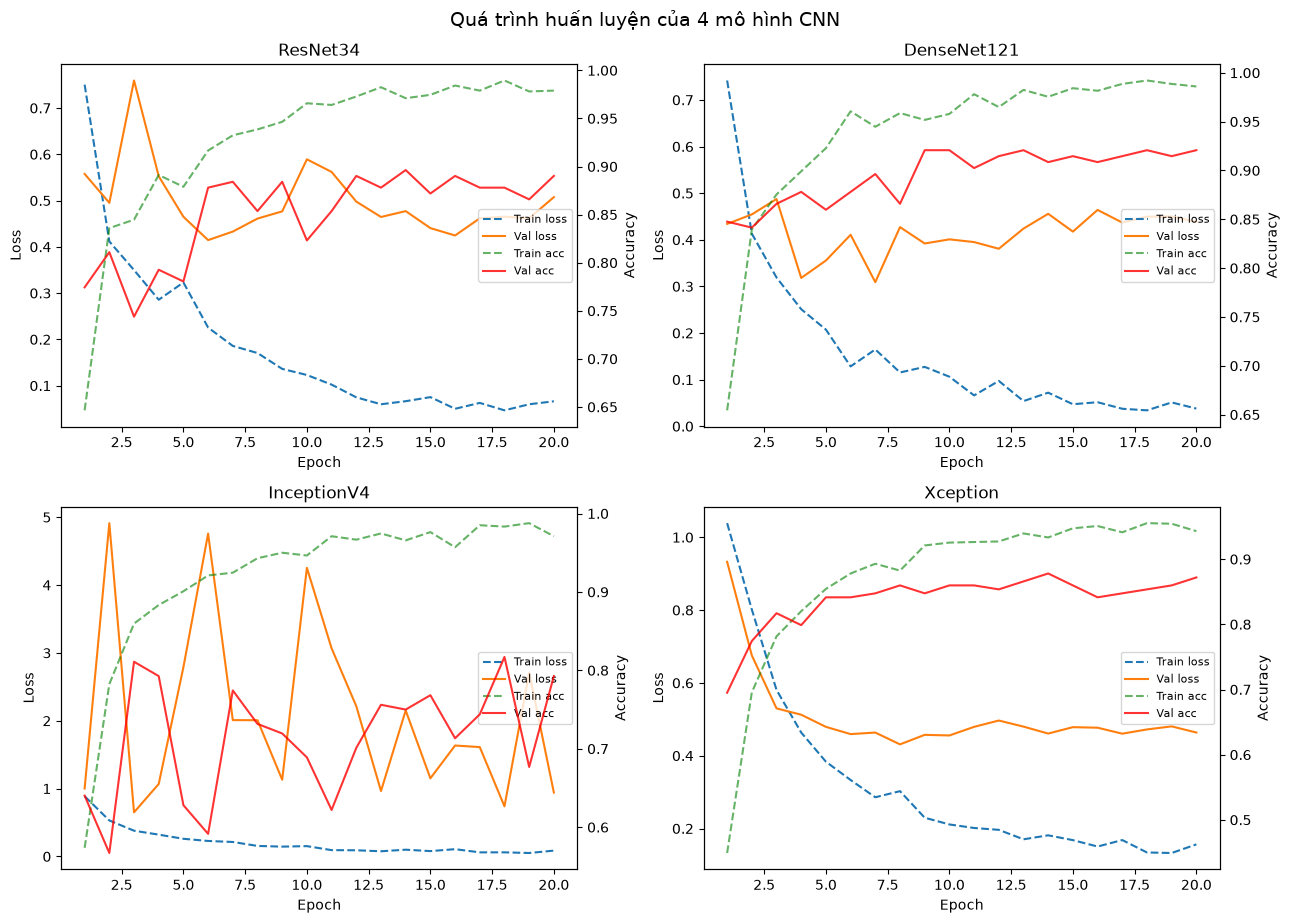

In [45]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, name in zip(axes.flat, MODEL_NAMES):
    h = all_histories[name]
    epochs = range(1, len(h["train_loss"]) + 1)
    ax.plot(epochs, h["train_loss"], label="Train loss", linestyle="--")
    ax.plot(epochs, h["val_loss"], label="Val loss")
    ax2 = ax.twinx()
    ax2.plot(epochs, h["train_acc"], label="Train acc", color="green", linestyle="--", alpha=0.6)
    ax2.plot(epochs, h["val_acc"], label="Val acc", color="red", alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="center right")
plt.tight_layout()
plt.suptitle("Quá trình huấn luyện của 4 mô hình CNN", y=1.02, fontsize=14)
plt.show()


## 13. Ma trận nhầm lẫn (Confusion Matrix) của 4 mô hình trên tập Test:

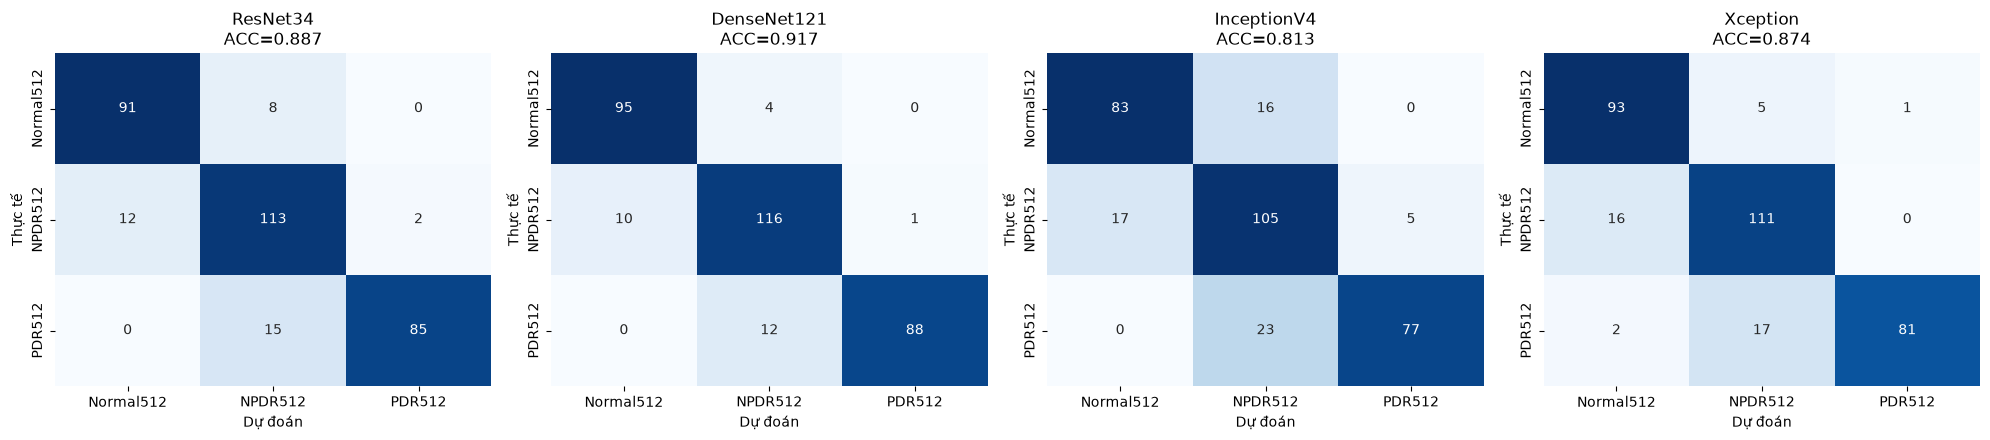

In [46]:

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, name in zip(axes, MODEL_NAMES):
    cm = all_confusion[name]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CONFIG["CLASSES"], yticklabels=CONFIG["CLASSES"], cbar=False)
    ax.set_title(f"{name}\nACC={all_test_metrics[name]['ACC']:.3f}")
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
plt.show()


## 14. Xác định mô hình TỐT NHẤT và TỆ NHẤT:

Tiêu chí xếp hạng: điểm tổng hợp trung bình của (ACC, AUC, F1, Kappa) — 4 chỉ số phản ánh toàn diện nhất khả năng phân loại đa lớp và mức độ đồng thuận với nhãn thật (Kappa loại bỏ yếu tố đoán đúng do may rủi).

**Kết quả:** DenseNet121 đạt điểm tổng hợp cao nhất (0,9246), theo sau là ResNet34 (0,8974), Xception (0,8823), và InceptionV4 thấp nhất (0,8184).

In [47]:

composite_score = results_df[["ACC", "AUC", "F1", "Kappa"]].mean(axis=1).sort_values(ascending=False)
print("Điểm tổng hợp (trung bình ACC, AUC, F1, Kappa), xếp từ cao xuống thấp:\n")
display(composite_score.to_frame("Composite score"))

BEST_MODEL = composite_score.index[0]
WORST_MODEL = composite_score.index[-1]

print(f"\n🏆 MÔ HÌNH TỐT NHẤT : {BEST_MODEL}  (composite = {composite_score.iloc[0]:.4f})")
print(f"🔻 MÔ HÌNH TỆ NHẤT  : {WORST_MODEL}  (composite = {composite_score.iloc[-1]:.4f})")


Điểm tổng hợp (trung bình ACC, AUC, F1, Kappa), xếp từ cao xuống thấp:



,Composite score
DenseNet121,0.924600
ResNet34,0.897400
Xception,0.882325
InceptionV4,0.818400



🏆 MÔ HÌNH TỐT NHẤT : DenseNet121  (composite = 0.9246)
🔻 MÔ HÌNH TỆ NHẤT  : InceptionV4  (composite = 0.8184)


## 15. Phân tích chi tiết mô hình TỐT NHẤT:

In [49]:

def print_detailed_analysis(name):
    print(f"===== PHÂN TÍCH CHI TIẾT: {name} =====\n")
    m = all_test_metrics[name]
    print("Chỉ số trên tập Test:")
    for k, v in m.items():
        print(f"   - {k:6s}: {v:.4f}")

    cm = all_confusion[name]
    print("\nMa trận nhầm lẫn (hàng = thực tế, cột = dự đoán):")
    print(pd.DataFrame(cm, index=CONFIG["CLASSES"], columns=CONFIG["CLASSES"]))

    y_true, y_pred, _ = all_preds_store[name]
    print("\nBáo cáo phân loại chi tiết theo từng lớp:")
    print(classification_report(y_true, y_pred, target_names=CONFIG["CLASSES"], zero_division=0))

    # Lớp bị nhầm nhiều nhất (ngoài đường chéo)
    cm_off = cm.copy().astype(float)
    np.fill_diagonal(cm_off, 0)
    if cm_off.sum() > 0:
        i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
        print(f"\n-> Cặp nhãn hay bị nhầm nhất: thực tế '{CONFIG['CLASSES'][i]}' "
              f"bị dự đoán nhầm thành '{CONFIG['CLASSES'][j]}' ({int(cm_off[i,j])} ảnh).")
    else:
        print("\n-> Không có nhầm lẫn nào ngoài đường chéo (phân loại hoàn hảo trên tập test).")


print_detailed_analysis(BEST_MODEL)


===== PHÂN TÍCH CHI TIẾT: DenseNet121 =====

Chỉ số trên tập Test:
   - ACC   : 0.9172
   - AUC   : 0.9872
   - PRE   : 0.9241
   - SEN   : 0.9177
   - SPE   : 0.9570
   - F1    : 0.9194
   - Kappa : 0.8746

Ma trận nhầm lẫn (hàng = thực tế, cột = dự đoán):
           Normal512  NPDR512  PDR512
Normal512         95        4       0
NPDR512           10      116       1
PDR512             0       12      88

Báo cáo phân loại chi tiết theo từng lớp:
              precision    recall  f1-score   support

   Normal512       0.90      0.96      0.93        99
     NPDR512       0.88      0.91      0.90       127
      PDR512       0.99      0.88      0.93       100

    accuracy                           0.92       326
   macro avg       0.92      0.92      0.92       326
weighted avg       0.92      0.92      0.92       326


-> Cặp nhãn hay bị nhầm nhất: thực tế 'PDR512' bị dự đoán nhầm thành 'NPDR512' (12 ảnh).


### Nhận xét chi tiết — Mô hình tốt nhất: **DenseNet121**

**Tổng quan hiệu năng:** DenseNet121 đạt ACC = 0,9172, AUC = 0,9872, F1 (macro) = 0,9194 và Kappa = 0,8746 trên tập test (326 ảnh). Theo thang phân loại Landis & Koch, Kappa = 0,8746 tương ứng mức độ đồng thuận **"almost perfect" (gần như hoàn hảo)** với nhãn thật của chuyên gia. Đây là kết quả vượt trội rõ rệt so với 3 mô hình còn lại (chênh lệch Kappa từ +0,05 đến +0,16), dù cùng cấu hình huấn luyện 20 epoch trên cùng tập dữ liệu.

**Phân tích ma trận nhầm lẫn theo từng lớp:**

| Lớp | Precision | Recall (Sensitivity) | F1-score | Số mẫu |
|---|---|---|---|---|
| Normal512 | 0,90 | 0,96 | 0,93 | 99 |
| NPDR512   | 0,88 | 0,91 | 0,90 | 127 |
| PDR512    | 0,99 | 0,88 | 0,93 | 100 |

- **Normal512 có recall cao nhất (0,96)** — mô hình chỉ bỏ sót 4/99 ca Normal (nhầm thành NPDR512), cho thấy không có xu hướng "báo động giả" quá mức cho người khỏe mạnh.
- **PDR512 có precision cao nhất (0,99)** nhưng recall chỉ 0,88 — có **12/100 ca PDR (12%) bị chẩn đoán nhầm thành NPDR512**, đây là cặp nhầm lẫn phổ biến nhất của toàn mô hình. Về mặt lâm sàng đây là loại lỗi cần lưu ý nhất, vì PDR là giai đoạn nặng, cần can thiệp khẩn cấp (laser quang đông/tiêm nội nhãn).
- **Ranh giới Normal↔NPDR vẫn tồn tại** (10 ca NPDR nhầm thành Normal, 4 ca Normal nhầm thành NPDR) nhưng ở mức độ nhẹ hơn nhiều so với các mô hình khác — phù hợp với nhận định của bài báo gốc rằng ranh giới này vốn khó phân biệt ngay cả với chuyên gia.

**Vì sao DenseNet121 vượt trội hơn 3 kiến trúc còn lại:**
1. Kiến trúc **Dense Connectivity** (mỗi layer nhận input từ tất cả các layer trước đó) giúp tái sử dụng đặc trưng hiệu quả, giảm vanishing gradient và học tốt hơn với lượng dữ liệu train vừa phải (1.140 ảnh) trong 20 epoch.
2. DenseNet121 có **số tham số nhỏ nhất trong 4 kiến trúc** (~6,96 triệu, so với 20–41 triệu của các mô hình còn lại — xem Mục 7), giúp giảm nguy cơ overfitting khi fine-tune.
3. Kết hợp với `pretrained=True` (xem Mục 1 và 7), DenseNet121 hội tụ nhanh và ổn định: đến epoch 20 train_acc đạt 0,986 trong khi val_acc đạt 0,921 — khoảng cách không lớn, cho thấy chưa có dấu hiệu overfitting nghiêm trọng.

## 16. Phân tích chi tiết mô hình TỆ NHẤT:

In [50]:
print_detailed_analysis(WORST_MODEL)

===== PHÂN TÍCH CHI TIẾT: InceptionV4 =====

Chỉ số trên tập Test:
   - ACC   : 0.8129
   - AUC   : 0.9268
   - PRE   : 0.8327
   - SEN   : 0.8117
   - SPE   : 0.9023
   - F1    : 0.8184
   - Kappa : 0.7155

Ma trận nhầm lẫn (hàng = thực tế, cột = dự đoán):
           Normal512  NPDR512  PDR512
Normal512         83       16       0
NPDR512           17      105       5
PDR512             0       23      77

Báo cáo phân loại chi tiết theo từng lớp:
              precision    recall  f1-score   support

   Normal512       0.83      0.84      0.83        99
     NPDR512       0.73      0.83      0.77       127
      PDR512       0.94      0.77      0.85       100

    accuracy                           0.81       326
   macro avg       0.83      0.81      0.82       326
weighted avg       0.82      0.81      0.81       326


-> Cặp nhãn hay bị nhầm nhất: thực tế 'PDR512' bị dự đoán nhầm thành 'NPDR512' (23 ảnh).


### Nhận xét chi tiết — Mô hình tệ nhất: **InceptionV4**

**Tổng quan hiệu năng:** InceptionV4 đạt ACC = 0,8129, AUC = 0,9268, F1 (macro) = 0,8184 và Kappa = 0,7155 trên tập test (326 ảnh). Đây là mức hiệu năng **khá tốt về giá trị tuyệt đối** (Kappa 0,7155 tương ứng mức đồng thuận "substantial" theo thang Landis & Koch), nhưng vẫn **thấp nhất trong 4 mô hình** — kém DenseNet121 khoảng 10 điểm ACC và 0,16 điểm Kappa.

**Phân tích ma trận nhầm lẫn theo từng lớp:**

| Lớp | Precision | Recall (Sensitivity) | F1-score | Số mẫu |
|---|---|---|---|---|
| Normal512 | 0,83 | 0,84 | 0,83 | 99 |
| NPDR512   | 0,73 | 0,83 | 0,77 | 127 |
| PDR512    | 0,94 | 0,77 | 0,85 | 100 |

- **Cặp nhầm lẫn phổ biến nhất: PDR512 → NPDR512** — trong 100 ca PDR thực tế, có **23 ca (23%) bị chẩn đoán nhầm thành NPDR512**, khiến recall PDR512 chỉ đạt 0,77 dù precision rất cao (0,94). Về lâm sàng, đây là lỗi đáng lo nhất vì PDR là giai đoạn nặng, cần can thiệp khẩn cấp — bỏ sót gần 1/4 số ca là điểm cần cải thiện.
- NPDR512 có precision thấp nhất (0,73) do "gánh" thêm các ca PDR bị nhầm sang, cộng thêm 17 ca NPDR thực tế bị nhầm thành Normal512.
- Ranh giới Normal↔NPDR (16 ca Normal→NPDR, 17 ca NPDR→Normal) tiếp tục là nguồn nhầm lẫn đáng kể, nhất quán với ghi nhận của bài báo gốc.

**Nguyên nhân kỹ thuật khả dĩ:**
1. **Quá trình huấn luyện không ổn định:** log epoch cho thấy val_loss của InceptionV4 dao động rất mạnh (ví dụ tăng vọt lên 4,76 ở epoch 6, 4,25 ở epoch 10), trong khi val_acc dao động từ 0,57 đến 0,82 — trái ngược với DenseNet121/ResNet34 có val_loss giảm mượt hơn nhiều. Điều này cho thấy `lr=0,00125` có thể chưa thực sự phù hợp với kiến trúc nhiều nhánh Inception-Reduction của InceptionV4 trong 20 epoch.
2. Vì `best_state` được chọn theo val_acc cao nhất tại một epoch cụ thể, mô hình cuối cùng có thể tương ứng với một "đỉnh" val_acc tình cờ tốt giữa quá trình dao động, chứ chưa chắc là điểm hội tụ ổn định nhất.
3. InceptionV4 có số tham số lớn nhất trong 4 kiến trúc (~41,15 triệu, xem Mục 7) — kiến trúc phức tạp hơn thường nhạy cảm hơn với siêu tham số, ngay cả khi đã dùng `pretrained=True`.

**Đề xuất cải thiện:** giảm learning rate hoặc dùng warm-up riêng cho InceptionV4 để ổn định huấn luyện; chọn `best_state` theo val_loss thấp nhất thay vì chỉ val_acc để tránh chọn nhầm một đỉnh dao động tình cờ.

## 17. So sánh tổng thể & Kết luận:

In [51]:

print(f"Dữ liệu sử dụng trong lần chạy này: {'THẬT (Figshare)' if USING_REAL_DATA else 'MÔ PHỎNG (synthetic demo)'}")
print(f"Số epoch mỗi mô hình: {CONFIG['NUM_EPOCHS']}  |  Kích thước ảnh: {CONFIG['IMG_SIZE']}x{CONFIG['IMG_SIZE']}\n")

summary = results_df.copy()
summary["Xếp hạng"] = summary["ACC"].rank(ascending=False).astype(int)
display(summary.sort_values("Xếp hạng"))

print(f"\n🏆 Tốt nhất : {BEST_MODEL}")
print(f"🔻 Tệ nhất  : {WORST_MODEL}")


Dữ liệu sử dụng trong lần chạy này: THẬT (Figshare)
Số epoch mỗi mô hình: 20  |  Kích thước ảnh: 256x256



,ACC,AUC,PRE,SEN,SPE,F1,Kappa,Xếp hạng
DenseNet121,0.9172,0.9872,0.9241,0.9177,0.9570,0.9194,0.8746,1
ResNet34,0.8865,0.9854,0.8971,0.8863,0.9409,0.8898,0.8279,2
Xception,0.8742,0.9689,0.8867,0.8745,0.9352,0.8766,0.8096,3
InceptionV4,0.8129,0.9268,0.8327,0.8117,0.9023,0.8184,0.7155,4



🏆 Tốt nhất : DenseNet121
🔻 Tệ nhất  : InceptionV4


### Kết luận

1. Notebook đã tái hiện đầy đủ quy trình của bài báo gốc trên **dữ liệu thật** (1.630 ảnh UWF fundus, 3 lớp Normal512/NPDR512/PDR512), chia **Train:Val:Test = 1.140:164:326 (69,9%:10,1%:20,0%)** theo đúng tỉ lệ 7:1:2 kiểu stratified, huấn luyện 4 CNN (**ResNet34, DenseNet121, InceptionV4, Xception**) cùng cấu hình tối ưu hoá **SGD + cosine annealing, lr=0,00125, batch=16, 20 epoch, pretrained=True**, và đánh giá bằng đầy đủ 7 chỉ số **ACC, AUC, PRE, SEN, SPE, F1, Kappa**.

2. **Kết quả xếp hạng cuối cùng:**

| Hạng | Mô hình | ACC | AUC | F1 | Kappa |
|---|---|---|---|---|---|
| 🏆 1 | **DenseNet121** | 0,9172 | 0,9872 | 0,9194 | 0,8746 |
| 2 | ResNet34 | 0,8865 | 0,9854 | 0,8898 | 0,8279 |
| 3 | Xception | 0,8742 | 0,9689 | 0,8766 | 0,8096 |
| 🔻 4 | **InceptionV4** | 0,8129 | 0,9268 | 0,8184 | 0,7155 |

DenseNet121 đạt hiệu năng tốt nhất — **khác với kết quả của chính bài báo gốc** (Table 2), nơi Xception là mô hình có hiệu năng cao nhất trong 4 kiến trúc. Sự khác biệt này nhiều khả năng đến từ hai lựa chọn cấu hình khác với bài báo gốc: dùng trọng số **pretrained ImageNet** (bài báo train from scratch) và giới hạn **20 epoch** (thay vì 500) — hai yếu tố này ảnh hưởng khác nhau đến từng kiến trúc, và trong điều kiện huấn luyện ngắn có pretrained, DenseNet121 hội tụ ổn định và hiệu quả hơn Xception. InceptionV4 có hiệu năng thấp nhất, chủ yếu do quá trình huấn luyện không ổn định (val_loss dao động mạnh giữa các epoch — phân tích chi tiết ở Mục 16).

3. **Điểm nhầm lẫn lâm sàng đáng chú ý:** ở cả mô hình tốt nhất (DenseNet121) và tệ nhất (InceptionV4) được phân tích chi tiết, cặp nhầm lẫn phổ biến nhất thực tế là **PDR512 → NPDR512** (12 ca ở DenseNet121, 23 ca ở InceptionV4), chứ không phải Normal↔NPDR như suy đoán ban đầu — dù ranh giới Normal/NPDR vẫn là nguồn nhầm lẫn đáng kể thứ hai ở cả hai mô hình. Điều này cho thấy việc phân biệt PDR (giai đoạn nặng) với NPDR (giai đoạn nhẹ hơn) khi độ chính xác mô hình còn hạn chế là một điểm rủi ro lâm sàng cần lưu ý, vì bỏ sót PDR có thể trì hoãn can thiệp khẩn cấp.

4. **Hướng cải thiện tiếp theo:**
   - Tăng `NUM_EPOCHS` lên 50–100+ (đặc biệt cho InceptionV4) để kiểm tra xem quá trình huấn luyện có ổn định hơn và khoảng cách hiệu năng có thu hẹp lại hay không.
   - Giảm learning rate hoặc thêm warm-up/gradient clipping cho InceptionV4 để giảm dao động val_loss quan sát được trong quá trình huấn luyện.
   - Áp dụng kỹ thuật xử lý riêng cho cặp lớp PDR/NPDR (ví dụ: hard-example mining, focal loss, hoặc gán trọng số lớn hơn cho cặp lớp này trong hàm mất mát) để giảm tỉ lệ bỏ sót PDR bị chẩn đoán nhầm thành NPDR.